# Sky-Model Visualization & Sanity Checks

Nothing here is required to run the pipeline. Use it to eyeball a single
snapshot before batch-processing, or to debug a result that looks off.


## 1. Imports & constants

In [1]:
import numpy as np
import h5py
import yt
from astropy.io import fits
import matplotlib.pyplot as plt
%matplotlib inline

# Physical constants (CGS), as yt quantities.
H_PLANCK = yt.YTQuantity(6.62607015e-27, "erg*s")
C_LIGHT  = yt.YTQuantity(2.99792458e10, "cm/s")
K_BOLTZ  = yt.YTQuantity(1.380649e-16, "erg/K")
SOLAR_MASS_G = 1.989e33
PC_TO_CM = 3.086e18


## 2. Load a snapshot and register dust fields

Point `SNAPSHOT_PATH` at one `.hdf5` file. The cell reads the unit base from
the header (so it works for any run) and registers the same derived dust
fields used by `skymodel_generation.py`.

In [2]:
SNAPSHOT_PATH = "snapshots/snapshot_170.hdf5"  
TELESCOPE = "ALMA"                          # "ALMA" or "VLA"

# Telescope presets: dust opacity and observing frequency.
PRESETS = {"ALMA": (1.84, 338e9), "VLA": (0.33, 33e9)}
kappa_val, nu_val = PRESETS[TELESCOPE]
kappa_nu = yt.YTQuantity(kappa_val, "cm**2/g")
nu = yt.YTQuantity(nu_val, "Hz")

with h5py.File(SNAPSHOT_PATH, "r") as f:
    header = f["Header"].attrs
    unit_base = {
        "UnitLength_in_cm": header["UnitLength_In_CGS"],
        "UnitMass_in_g": header["UnitMass_In_CGS"],
        "UnitVelocity_In_CGS": header["UnitVelocity_In_CGS"],
        "UnitB": 1e4,
    }
    box_size_pc = header["BoxSize"] * unit_base["UnitLength_in_cm"] / PC_TO_CM

ds = yt.load(SNAPSHOT_PATH, unit_base=unit_base)
ad = ds.all_data()
print("Box size: %.4f pc" % box_size_pc)


yt : [INFO     ] 2026-07-23 20:05:21,402 ComovingIntegrationOn != 1 or (not found and OmegaLambda is 0.0), so we are turning off Cosmology.
yt : [INFO     ] 2026-07-23 20:05:21,595 Parameters: current_time              = 1.9194197952049642e-05
yt : [INFO     ] 2026-07-23 20:05:21,598 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-07-23 20:05:21,600 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-23 20:05:21,603 Parameters: domain_right_edge         = [0.1 0.1 0.1]
yt : [INFO     ] 2026-07-23 20:05:21,604 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-07-23 20:05:21,670 Allocating for 1.183e+05 particles


Box size: 0.1000 pc


In [3]:
def _dust_temp(field, data):
    return data[("PartType0", "Dust_Temperature")] * yt.YTQuantity(1.0, "K")

def _dust_mass(field, data):
    return 0.01 * data[("PartType0", "mass")]

def _dust_density(field, data):
    return 0.01 * data[("PartType0", "density")] # Since dust 1% of the total density

def _planck_nu(field, data):
    T = data[("PartType0", "Dust_Temperature_K")]
    x = (H_PLANCK * nu) / (K_BOLTZ * T)
    bnu = (2 * H_PLANCK * nu**3 / C_LIGHT**2) / (np.exp(x) - 1)
    return bnu / yt.YTQuantity(1.0, "sr")

def _dust_emissivity_nu(field, data):
    return kappa_nu * data[("PartType0", "dust_density")] * data[("PartType0", "b_nu")]

def _number_density(field, data):
    m_H = yt.YTQuantity(1.6736e-24, "g")
    return data[("PartType0", "density")] / (1.3 * m_H)

def _gas_density(field, data):
    return data[("PartType0", "density")] * 0.99 # Since gas is 99% of the total density

ds.add_field(("PartType0", "number_density"), function=_number_density,
             units="cm**-3", sampling_type="particle", force_override=True)
ds.add_field(("PartType0", "gas_density"), function=_gas_density,
             units="g*cm**-3", sampling_type="particle", force_override=True)
ds.add_field(("PartType0", "Dust_Temperature_K"), function=_dust_temp,
             units="K", sampling_type="particle", force_override=True)
ds.add_field(("PartType0", "dust_mass"), function=_dust_mass,
             units="g", sampling_type="particle", force_override=True)
ds.add_field(("PartType0", "dust_density"), function=_dust_density,
             units="g/cm**3", sampling_type="particle", force_override=True)
ds.add_field(("PartType0", "b_nu"), function=_planck_nu,
             units="erg/s/cm**2/Hz/sr", sampling_type="local", force_override=True)
ds.add_field(("PartType0", "dust_emissivity_nu"), function=_dust_emissivity_nu,
             units="erg/s/cm**3/Hz/sr", sampling_type="local", force_override=True)
print("Derived fields registered.")


Derived fields registered.


## 3. Quick disk mass check

Sum the dust mass of dense gas (a rough proxy for the disk) and report it in
solar masses. Useful as a first 'is this snapshot sensible?' number.

In [4]:
n_thresh = 1e9   # number-density cut for "disk" gas (cm^-3)
msk = np.where(ad[("PartType0", "number_density")] > n_thresh)
disk_dust_mass = ad[("PartType0", "dust_mass")][msk]
print("Disk dust mass (n > %.0e): %.3e Msun"
      % (n_thresh, float(np.sum(disk_dust_mass) / SOLAR_MASS_G)))

# Protostar (sink) luminosity, if present.
if ("PartType5", "StarLuminosity_Solar") in ds.field_list:
    print("Total sink luminosity: %.3f Lsun"
          % float(np.sum(ad[("PartType5", "StarLuminosity_Solar")])))


Disk dust mass (n > 1e+09): 2.722e-03 Msun
Total sink luminosity: 43.045 Lsun


## 4. Projected dust-emissivity and density maps

Project the dust emissivity along a chosen axis, centred on the densest cell,
and pull out the fixed-resolution buffer (FRB) as a numpy array. This is the
exact quantity `skymodel_generation.py` converts into flux.

yt : [INFO     ] 2026-07-23 20:05:24,897 xlim = 0.000000 0.100000
yt : [INFO     ] 2026-07-23 20:05:24,899 ylim = 0.000000 0.100000
yt : [INFO     ] 2026-07-23 20:05:24,912 xlim = 0.000000 0.100000
yt : [INFO     ] 2026-07-23 20:05:24,915 ylim = 0.000000 0.100000
yt : [INFO     ] 2026-07-23 20:05:24,927 Making a fixed resolution buffer of (('PartType0', 'dust_emissivity_nu')) 800 by 800
yt : [INFO     ] 2026-07-23 20:05:30,062 max value is 1.87498e+11 at 0.0508241809590892 0.0492810874973900 0.0508447275028310
yt : [INFO     ] 2026-07-23 20:05:30,064 xlim = 0.000845 0.100845
yt : [INFO     ] 2026-07-23 20:05:30,066 ylim = 0.000824 0.100824
yt : [INFO     ] 2026-07-23 20:05:30,068 Making a fixed resolution buffer of (('PartType0', 'dust_emissivity_nu')) 800 by 800



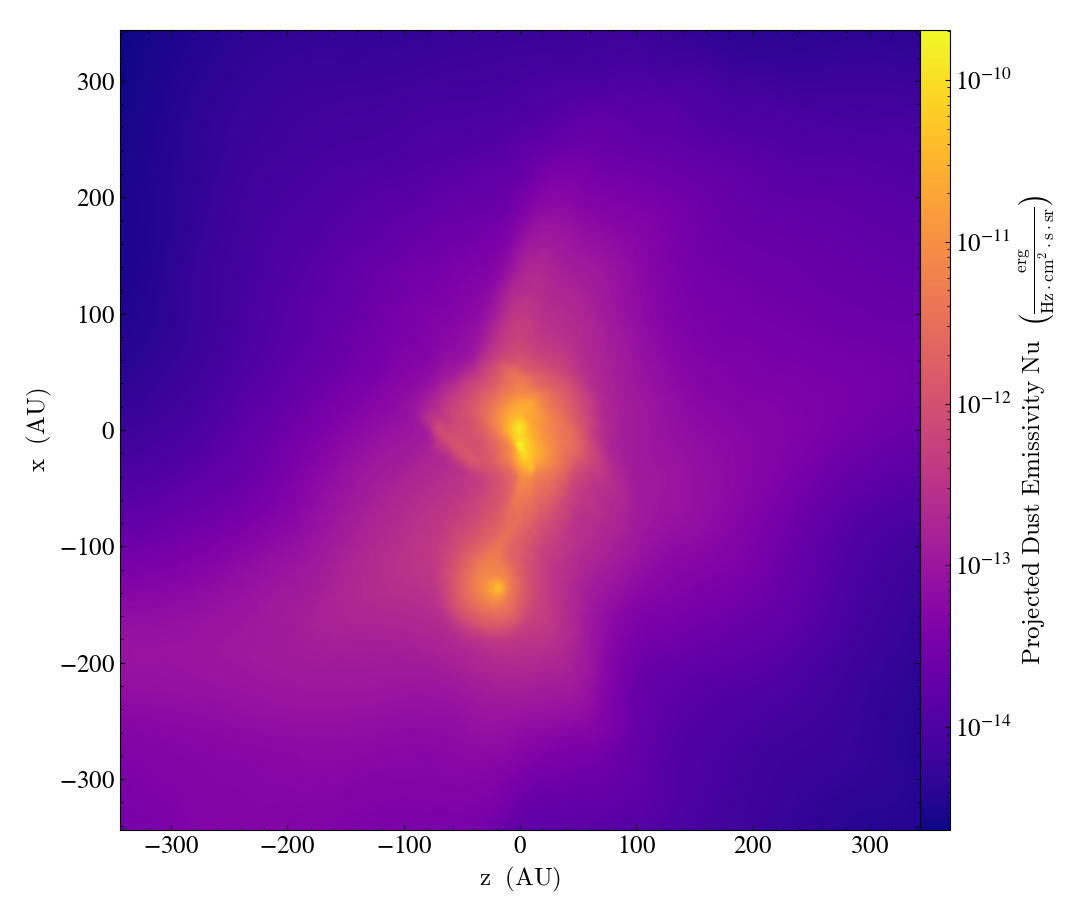

In [5]:
AXIS = "y"        # "x", "y" or "z"
ZOOM = 30           # zoom factor for the projection
RES = (800, 800)   # FRB resolution

field = ("PartType0", "dust_emissivity_nu")
prj = yt.ProjectionPlot(ds, AXIS, field, weight_field=None)
prj.set_cmap(field, "plasma")
prj.set_log(field, True)

_, cen = ds.find_max(("PartType0", "density"))
if AXIS == "x":
    prj.set_center((cen[1], cen[2]))
elif AXIS == "y":
    prj.set_center((cen[2], cen[0]))
elif AXIS == "z":
    prj.set_center((cen[0], cen[1]))
prj.zoom(ZOOM)
prj.show()

frb = prj.frb
prj_width_cm = prj.width[0].to("cm").d
prj_width_au = prj.width[0].to("AU").d
pixel_length_cm = prj_width_cm / RES[0]
pixel_area_cm2 = pixel_length_cm**2


yt : [INFO     ] 2026-07-23 20:06:00,951 xlim = 0.000000 0.100000
yt : [INFO     ] 2026-07-23 20:06:00,953 ylim = 0.000000 0.100000
yt : [INFO     ] 2026-07-23 20:06:00,961 xlim = 0.000000 0.100000
yt : [INFO     ] 2026-07-23 20:06:00,962 ylim = 0.000000 0.100000
yt : [INFO     ] 2026-07-23 20:06:00,965 Making a fixed resolution buffer of (('PartType0', 'gas_density')) 800 by 800


yt : [INFO     ] 2026-07-23 20:06:04,253 max value is 1.87498e+11 at 0.0508241809590892 0.0492810874973900 0.0508447275028310
yt : [INFO     ] 2026-07-23 20:06:04,255 xlim = 0.000824 0.100824
yt : [INFO     ] 2026-07-23 20:06:04,256 ylim = -0.000719 0.099281
C:\Users\nachi\AppData\Local\Temp\ipykernel_42932\3623276185.py:26: DeprecationWarning: `plot_args` is deprecated. You can now pass arbitrary keyword arguments instead of a dictionary.
Deprecated since yt 4.1
  prj.annotate_marker(pos, coord_system="data", marker="o",
yt : [INFO     ] 2026-07-23 20:06:04,259 Making a fixed resolution buffer of (('PartType0', 'gas_density')) 800 by 800



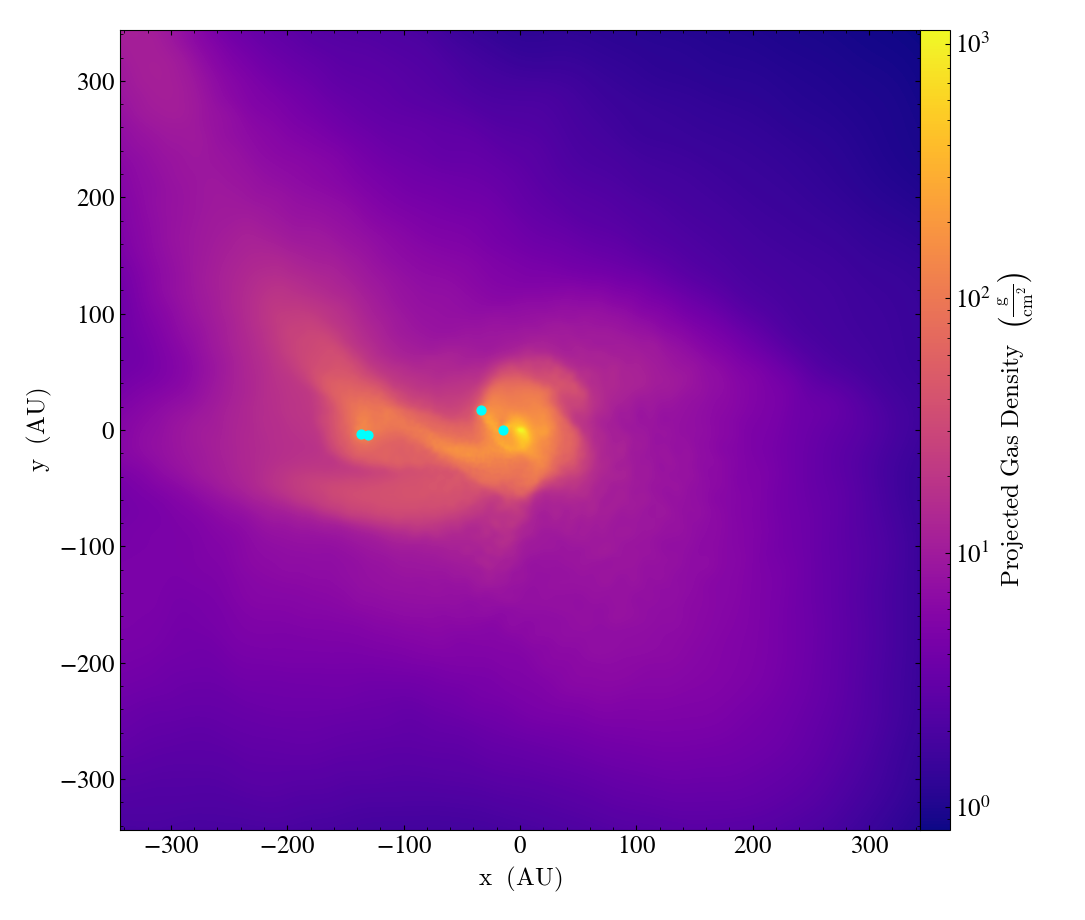

In [11]:
AXIS = "z"        # "x", "y" or "z"
ZOOM = 30           # zoom factor for the projection
RES = (800, 800)   # FRB resolution

field = ("PartType0", "gas_density")
prj = yt.ProjectionPlot(ds, AXIS, field, weight_field=None)
prj.set_cmap(field, "plasma")
prj.set_log(field, True)

_, cen = ds.find_max(("PartType0", "density"))
if AXIS == "x":
    prj.set_center((cen[1], cen[2]))
elif AXIS == "y":
    prj.set_center((cen[2], cen[0]))
elif AXIS == "z":
    prj.set_center((cen[0], cen[1]))
prj.zoom(ZOOM)

# --- Label the sink (PartType5) particles ---
sx = ad[("PartType5", "particle_position_x")]
sy = ad[("PartType5", "particle_position_y")]
sz = ad[("PartType5", "particle_position_z")]

for i in range(len(sx)):
    pos = [sx[i].d, sy[i].d, sz[i].d]          # full 3-D position in code units
    prj.annotate_marker(pos, coord_system="data", marker="o",
                        plot_args={"color": "cyan", "s": 40})

prj.show()

frb = prj.frb
prj_width_cm = prj.width[0].to("cm").d
prj_width_au = prj.width[0].to("AU").d
pixel_length_cm = prj_width_cm / RES[0]
pixel_area_cm2 = pixel_length_cm**2

## 5. Flux maps as seen from a star-forming region

Convert the projected emissivity into flux density (mJy/pixel) for each region
distance and display it. This is what the sky model encodes.

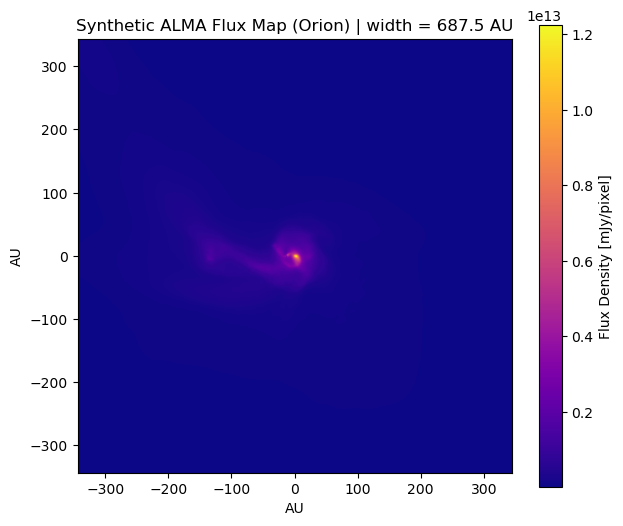

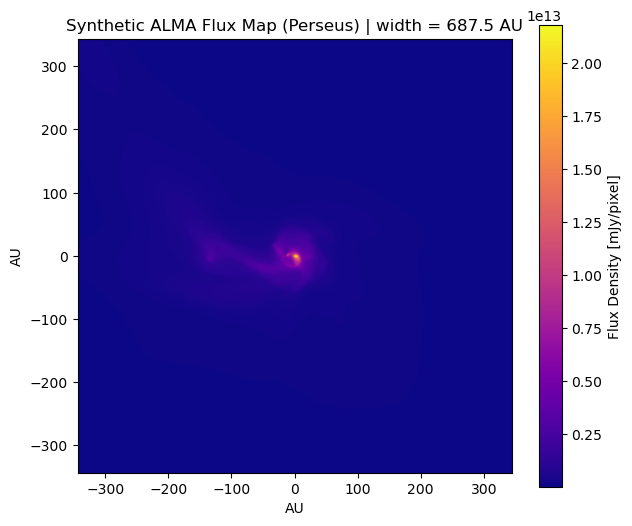

In [12]:
REGIONS = {"Orion": 400.0, "Perseus": 300.0}   # name -> distance (pc)
projected = frb[field].d

extent = [-prj_width_au/2, prj_width_au/2, -prj_width_au/2, prj_width_au/2]
for region, dist_pc in REGIONS.items():
    dist_cm = dist_pc * PC_TO_CM
    s_nu_jy = projected * (pixel_area_cm2 / dist_cm**2) * 1e23   # Jy/pixel
    s_nu_mjy = s_nu_jy * 1e3

    plt.figure(figsize=(7, 6))
    plt.imshow(s_nu_mjy, origin="lower", cmap="plasma", extent=extent)
    plt.colorbar(label="Flux Density [mJy/pixel]")
    plt.title("Synthetic %s Flux Map (%s) | width = %.1f AU"
              % (TELESCOPE, region, prj_width_au))
    plt.xlabel("AU"); plt.ylabel("AU")
    plt.show()


## 6. Inspect a CASA-observed image

After running `casa_simulation.py`, point this at one of the
`*_sim_observed_pbcor.fits` images to compare the 'observed' disk against the
sky model above. 

AU per pixel: 11.999999999999519


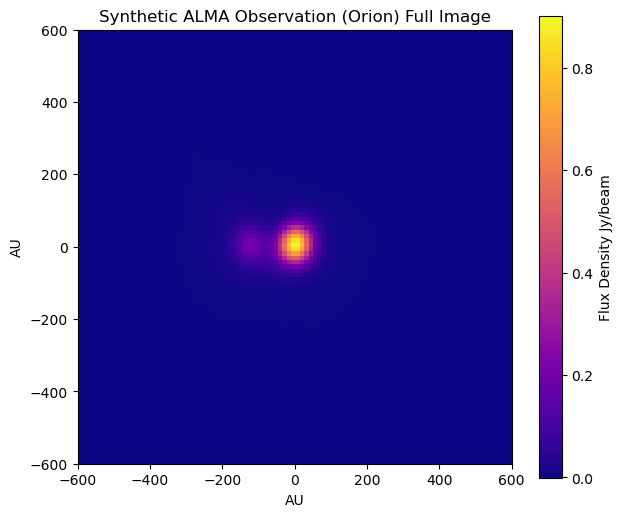

In [13]:
OBSERVED_PATH = r"C:\Users\nachi\Documents\JupyterNotebooksLinux\Cosmic Origins\casa_main\pbcor_imgs\ALMA_snapshot_170_axis_z_Orion_sim_observed_pbcor.fits"
SITE = "Orion"     # for the distance used to set the AU scale

dat = fits.open(OBSERVED_PATH)
image = dat[0].data[0][0]
obs_header = dat[0].header
pixscale_arcsec = abs(obs_header["CDELT1"]) * 3600
distance_pc = REGIONS.get(SITE, 300.0)
au_per_pixel = pixscale_arcsec * distance_pc
print("AU per pixel:", au_per_pixel)

ny, nx = image.shape
full_width = au_per_pixel * nx
full_extent = [-full_width/2, full_width/2, -full_width/2, full_width/2]

plt.figure(figsize=(7, 6))
plt.imshow(image, origin="lower", cmap="plasma", extent=full_extent)
plt.colorbar(label="Flux Density %s" % obs_header.get("BUNIT", ""))
plt.title("Synthetic %s Observation (%s) Full Image" % (TELESCOPE, SITE))
plt.xlabel("AU"); plt.ylabel("AU")
plt.show()


In [14]:
import json

with open(r'C:\Users\nachi\Documents\JupyterNotebooksLinux\Cosmic Origins\casa_main\fitting_results.json',"r") as file:
    results_dict = json.load(file)

In [15]:
results_dict['170']['Orion']['z']

{'Rmaj': 0.1508899383350528,
 'Rmaj_err': 0.01292307049454508,
 'Rmin': 0.12097975994914029,
 'Rmin_err': 0.01762856068950437,
 'pa': 100.30086774747048,
 'pa_err': 21.53596708402811,
 'flux': 1.553114645766011,
 'flux_err': 0.06118588803903187,
 'flux_peak': 0.8657675893876909,
 'flux_peak_err': 0.023437140351643272,
 'inc': 36.70007470113732,
 'radius_AU': 30.17798766701056,
 'radius_AU_Tobin': 51.25772852146168,
 'rms_residual': 0.02160961085376011,
 'peak_residual': 0.21332570910453796,
 'min_residual': -0.05087250471115112,
 'peak_residual_fraction': 0.24640066424224927,
 'snr': 40.06400648519989,
 'dust_mass_Msun': 0.0018009471382693328}